![Attribution Targets](img/attribution_targets/attribution_targets_banner.png)

# Attribution Targets

This tutorial walks through the **attribution targets API**, demonstrating how to attribute back from arbitrary tokens, functions thereof, or abstract concept directions in the residual stream.

The `AttributionTargets` class (in `circuit_tracer.attribution.targets`) accepts four input formats:

| Input type | Mode | Description |
|---|---|---|
| `None` | Salient logits | Auto-selects the most probable next tokens via `max_n_logits` / `desired_logit_prob` (default) |
| `Sequence[str]` | Token strings | Attribute from explicitly named tokens, e.g. `["▁Austin", "▁Dallas"]` |
| `torch.Tensor` | Token ID tensor | Attribute from specific vocabulary indices |
| `Sequence[TargetSpec]` | Custom target | Attribute from arbitrary residual-stream directions via `CustomTarget(token_str, prob, vec)` |

We will demo the use of all four input formats using the capital-city prompt you may be familiar with from other demos: the model must resolve *"capital of the state containing Dallas"* via multi-hop reasoning (Dallas → Texas → Austin). After comparing the top features discovered under each mode, we will apply interventions to elucidate two `CustomTarget` examples.

In [ ]:
# One-time dependency bootstrap for a fresh pod/kernel
# Run this cell once, then restart the kernel.

# %pip install --no-cache-dir -e /workspace/thesis_circuit_breaker

In [19]:
#@title Runtime + Hugging Face Setup (Local/Runpod) { display-mode: "form" }

import os
import sys
from pathlib import Path

IN_RUNPOD = os.environ.get("RUNPOD_POD_ID") is not None

print("Configuring local/Runpod environment...")

def _find_repo_root() -> Path | None:
    start = Path.cwd().resolve()
    for directory in [start, *start.parents]:
        if (directory / "circuit_tracer" / "__init__.py").is_file():
            return directory

    # On Runpod, repo is often under /workspace with different folder names.
    workspace = Path("/workspace")
    if workspace.is_dir():
        for child in workspace.iterdir():
            if child.is_dir() and (child / "circuit_tracer" / "__init__.py").is_file():
                return child

    # Optional explicit override for custom locations.
    repo_override = os.environ.get("CT_REPO_DIR")
    if repo_override:
        override_path = Path(repo_override).expanduser().resolve()
        if (override_path / "circuit_tracer" / "__init__.py").is_file():
            return override_path

    return None

_root = _find_repo_root()
if _root is not None:
    root_str = str(_root)
    if root_str not in sys.path:
        sys.path.insert(0, root_str)
    print(f"Repo root on sys.path: {_root}")

    # Ensure core project dependencies are present in the active kernel env.
    import importlib.util
    import subprocess

    required_modules = [
        "safetensors",
        "transformers",
        "tokenizers",
        "nnsight",
        "transformer_lens",
    ]
    missing = [m for m in required_modules if importlib.util.find_spec(m) is None]
    if missing:
        raise RuntimeError(
            "Missing dependencies detected: "
            f"{missing}. Install once in this kernel env with: `pip install -e {_root}` "
            "then restart kernel and rerun from the top."
        )

    # Pin HF stack to versions compatible with this repo (see pyproject.toml).
    # Newer transformers releases can remove symbols like BertForPreTraining and break lazy imports.
    from importlib.metadata import version as _pkg_version

    def _parse(v: str) -> tuple[int, int, int]:
        # Very small version parser: handles "4.57.3", "1.12.0", "2.4.1+cu124"
        core = v.split("+", 1)[0].strip()
        parts = core.split(".")
        nums: list[int] = []
        for p in parts[:3]:
            digits = "".join(ch for ch in p if ch.isdigit())
            nums.append(int(digits) if digits else 0)
        while len(nums) < 3:
            nums.append(0)
        return nums[0], nums[1], nums[2]

    def _lt(a: str, b: str) -> bool:
        return _parse(a) < _parse(b)

    def _gt(a: str, b: str) -> bool:
        return _parse(a) > _parse(b)

    def _gte(v: str, minimum: str) -> bool:
        return not _lt(v, minimum)

    def _pin_hf_stack() -> None:
        try:
            hf_hub_v = _pkg_version("huggingface_hub")
        except Exception:
            hf_hub_v = ""

        try:
            tf_v = _pkg_version("transformers")
        except Exception:
            tf_v = ""

        needs_pin = False
        if hf_hub_v and _gte(hf_hub_v, "1.0.0"):
            needs_pin = True

        if tf_v and (_lt(tf_v, "4.56.0") or _gt(tf_v, "4.57.3")):
            needs_pin = True

        if needs_pin:
            print("Pinning huggingface_hub + transformers to repo-compatible versions...")
            subprocess.check_call(
                [
                    sys.executable,
                    "-m",
                    "pip",
                    "install",
                    "-q",
                    "--no-cache-dir",
                    "huggingface_hub<1.0.0",
                    "transformers>=4.56.0,<=4.57.3",
                ]
            )
            raise RuntimeError(
                "Pinned huggingface_hub/transformers. Please restart the kernel, then rerun from the top."
            )

    _pin_hf_stack()
else:
    print(
        "Could not locate local circuit_tracer repo. "
        "Clone your repo into /workspace or set CT_REPO_DIR to your repo path."
    )

# Avoid torch import failures after dependency drift in long-lived pod environments.
# torch>=2.11 expects typing_extensions.TypeIs.
try:
    from typing_extensions import TypeIs  # type: ignore[attr-defined]
except Exception:
    print("typing_extensions is too old for current torch; upgrading typing_extensions...")
    %pip install -q --no-cache-dir "typing_extensions>=4.12.2"
    raise RuntimeError(
        "Installed typing_extensions>=4.12.2. Please restart the kernel, then rerun from the top."
    )

# Load local .env when available (useful for local runs). On Runpod, env vars are usually set in pod config.
try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

if load_dotenv is not None and _root is not None:
    _env_file = _root / ".env"
    if _env_file.is_file():
        load_dotenv(_env_file)
        print(f"Loaded {_env_file} (e.g. HF_TOKEN for Hugging Face).")

# Standardize token env names so huggingface_hub can pick it up reliably.
hf_token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_HUB_TOKEN")
if hf_token and not os.environ.get("HUGGINGFACE_HUB_TOKEN"):
    os.environ["HUGGINGFACE_HUB_TOKEN"] = hf_token

# Configure persistent cache/output paths when running on Runpod.
if IN_RUNPOD:
    persistent_root = Path(os.environ.get("RUNPOD_PERSISTENT_ROOT", "/workspace")).resolve()
    hf_home = persistent_root / "hf"
    cache_dirs = {
        "HF_HOME": hf_home,
        "HUGGINGFACE_HUB_CACHE": hf_home / "hub",
        "TRANSFORMERS_CACHE": hf_home / "transformers",
        "HF_DATASETS_CACHE": hf_home / "datasets",
        "TORCH_HOME": persistent_root / "torch",
        "CT_OUTPUT_DIR": persistent_root / "results" / "attribution_targets",
    }
    for key, path in cache_dirs.items():
        path.mkdir(parents=True, exist_ok=True)
        os.environ[key] = str(path)

    print("Runpod detected. Persistent storage configured:")
    print(f"  root={persistent_root}")
    for key in [
        "HF_HOME",
        "HUGGINGFACE_HUB_CACHE",
        "TRANSFORMERS_CACHE",
        "HF_DATASETS_CACHE",
        "TORCH_HOME",
        "CT_OUTPUT_DIR",
    ]:
        print(f"  {key}={os.environ[key]}")

from huggingface_hub import get_token

if get_token() is None:
    print(
        "No Hugging Face token in this environment. google/gemma-2-2b is gated: accept the "
        "license at https://huggingface.co/google/gemma-2-2b then set HF_TOKEN in your env."
    )
    print("If on Runpod: set HF_TOKEN in pod env vars and restart kernel.")
else:
    print("Hugging Face token detected; model/cache should be reusable across runs.")

Configuring local/Runpod environment...
Repo root on sys.path: /workspace/thesis_circuit_breaker
Runpod detected. Persistent storage configured:
  root=/workspace
  HF_HOME=/workspace/hf
  HUGGINGFACE_HUB_CACHE=/workspace/hf/hub
  TRANSFORMERS_CACHE=/workspace/hf/transformers
  HF_DATASETS_CACHE=/workspace/hf/datasets
  TORCH_HOME=/workspace/torch
  CT_OUTPUT_DIR=/workspace/results/attribution_targets
Hugging Face token detected; model/cache should be reusable across runs.


In [20]:
#%pip uninstall -y torch torchvision torchaudio
#%pip install --no-cache-dir --index-url https://download.pytorch.org/whl/cu124 torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1

In [21]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

True
NVIDIA RTX A4500


In [22]:
# @title Imports { display-mode: "form" }

from functools import partial

import torch

from circuit_tracer import ReplacementModel, attribute
from circuit_tracer.attribution.targets import CustomTarget
from circuit_tracer.utils import create_graph_files
from circuit_tracer.utils.demo_utils import (
    cleanup_cuda,
    display_ablation_chart,
    display_attribution_config,
    display_token_probs,
    display_topk_token_predictions,
    display_top_features_comparison,
    get_top_features,
    get_unembed_vecs,
)

/workspace/venvs/ct/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [23]:
# Runtime sanity checks (recommended to run first on each session)
import os
import torch

print(f"torch version: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"gpu: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: GPU not detected. Runs may be very slow on CPU.")

for key in [
    "HF_HOME",
    "HUGGINGFACE_HUB_CACHE",
    "TRANSFORMERS_CACHE",
    "HF_DATASETS_CACHE",
    "TORCH_HOME",
    "CT_OUTPUT_DIR",
]:
    print(f"{key}={os.environ.get(key, '<unset>')}")

print("HF token set:", bool(os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_HUB_TOKEN")))

torch version: 2.4.1+cu124
cuda available: True
gpu: NVIDIA RTX A4500
HF_HOME=/workspace/hf
HUGGINGFACE_HUB_CACHE=/workspace/hf/hub
TRANSFORMERS_CACHE=/workspace/hf/transformers
HF_DATASETS_CACHE=/workspace/hf/datasets
TORCH_HOME=/workspace/torch
CT_OUTPUT_DIR=/workspace/results/attribution_targets
HF token set: True


## Setup

Load the model and define helper functions. We use `google/gemma-2-2b` with the Gemma Scope transcoders, the same configuration used in the other demos. Change `backend` to `'nnsight'` if you prefer the NNSight backend.

In [24]:
import sys

model_name = "google/gemma-2-2b"
transcoder_name = "gemma"
backend = "transformerlens"  # change to 'nnsight' for the nnsight backend!

from circuit_tracer.utils import get_default_device

device = get_default_device()
print(f"Loading model on {device} (cuda > mps > cpu)")
if device.type == "cpu" and sys.platform == "darwin":
    _mps = getattr(torch.backends, "mps", None)
    _built = _mps.is_built() if _mps is not None else False
    _avail = _mps.is_available() if _mps is not None else False
    print(
        f"macOS: torch.backends.mps.is_built()={_built}, is_available()={_avail}. "
        "If both are False, this PyTorch is likely CPU-only (try pip/conda install per https://pytorch.org/get-started/locally/)."
    )
if device.type == "mps":
    print(
        "MPS: circuit_tracer sets PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 if unset (helps Gemma+transcoder load). "
        "After an MPS OOM, restart the kernel before retrying."
    )

model = ReplacementModel.from_pretrained(
    model_name, transcoder_name, dtype=torch.bfloat16, backend=backend, device=device
)

Loading model on cuda (cuda > mps > cpu)


Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer


## Basic Attribution Target Modes

This section explores the three simplest ways to specify attribution targets:

1. **Automatic Salient Logit Targets** (`None`) — the default mode; auto-selects the most probable next tokens.
2. **Token-String Targets** (`Sequence[str]`) — attribute from explicit token surface forms.
3. **Token-ID Targets** (`torch.Tensor`) — attribute from specific vocabulary indices (pre-tokenized equivalent of string targets).

> **Coming up:** After these basic modes, we explore two **custom attribution target** examples that let you attribute back from arbitrary residual-stream directions — a logit *difference* (`logit(Austin) − logit(Dallas)`) and an abstract *semantic concept* (`Capitals − States`).

In [27]:
# Define the prompt, shared attribution parameters, and the three reference tokens (`▁Austin`, `▁Dallas`, `▁Texas`). 

prompt1 = "Statement: For any triangle, the sum of any two sides is greater than the third side. Answer:"
prompt2 = "Statement: For any triangle, the sum of any two sides is greater than the third side. Answer with exactly one word: True or False."
prompt3 = "Statement: For any triangle, the sum of any two sides is less than the third side. Answer:"

prompt = prompt2

token_x, token_y = " True", " False"

# Shared attribution kwargs (apply to all runs)
# Note: max_n_logits / desired_logit_prob only apply to salient-logit mode
# Disk offload is preferred for larger graphs on Runpod/local sessions.
attr_kwargs = dict(
    batch_size=256,
    max_feature_nodes=8192,
    offload="disk",
    verbose=True,
)

# Resolve token ids for key tokens
tokenizer = model.tokenizer
idx_x = tokenizer.encode(token_x, add_special_tokens=False)[-1]
idx_y = tokenizer.encode(token_y, add_special_tokens=False)[-1]
idx_true  = tokenizer.encode("True", add_special_tokens=False)[-1]
idx_false = tokenizer.encode("False", add_special_tokens=False)[-1]
idx_yes   = tokenizer.encode("Yes", add_special_tokens=False)[-1]
idx_no    = tokenizer.encode("No", add_special_tokens=False)[-1]

# Bind the tokenizer and key tokens for display helpers
display_topk = partial(
    display_topk_token_predictions,
    tokenizer=tokenizer,
    key_tokens=[(token_x, idx_x), (token_y, idx_y), 
                ("True", idx_true), ("False", idx_false), 
                ("Yes", idx_yes), ("No", idx_no)],
)

# Show baseline token probabilities
input_ids = model.ensure_tokenized(prompt)
with torch.no_grad():
    baseline_logits, _ = model.get_activations(input_ids)

key_ids = [idx_x, idx_y, idx_true, idx_false, idx_yes, idx_no]
key_labels = [token_x, token_y, "True", "False", "Yes", "No"]
display_token_probs(baseline_logits, key_ids, key_labels, title="Baseline probabilities")

Token,Probability,Logit
True,1.427%,23.8750
False,0.219%,22.0000
True,2.31e-04,19.7500
False,2.75e-05,17.6250
Yes,1.29e-06,14.5625
No,2.90e-06,15.3750


### Automatic Target Selection — Salient Logits (`None`)

When `attribution_targets` is `None` (the default), `AttributionTargets` auto-selects the most probable next tokens until `desired_logit_prob` cumulative probability is reached (capped at `max_n_logits`). This is the standard mode used by `attribute_demo.ipynb`.

In [77]:
graph_salient = attribute(
    prompt=prompt, model=model,
    max_n_logits=10, desired_logit_prob=0.95,
    **attr_kwargs,
)
print(f"Salient-logits graph: {len(graph_salient.logit_targets)} targets, "
      f"{graph_salient.active_features.shape[0]} active features")

# Free CUDA memory before next run
cleanup_cuda()

Phase 0: Precomputing activations and vectors
Precomputation completed in 2.71s
Found 23738 active features
Phase 1: Running forward pass
Forward pass completed in 0.40s
Phase 2: Building input vectors
Using 10 salient logits with cumulative probability 0.5625
Will include 8192 of 23738 feature nodes
Input vectors built in 3.01s
Phase 3: Computing logit attributions
Logit attributions completed in 0.29s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 8192/8192 [00:09<00:00, 876.55it/s] 
Feature attributions completed in 9.35s
Attribution completed in 21.01s


Salient-logits graph: 10 targets, 23738 active features


### Token-String Targets — `Sequence[str]`

Pass a list of token strings (e.g., `["▁Austin", "▁Dallas"]`) to focus attribution on exactly those logits. Internally, each string is tokenized and its softmax probability and unembedding vector are computed automatically — you only need to supply the surface forms.

In [78]:
graph_str = attribute(
    prompt=prompt, model=model,
    attribution_targets=[token_x, token_y],
    **attr_kwargs,
)
print(f"String-targets graph: {len(graph_str.logit_targets)} targets, "
      f"{graph_str.active_features.shape[0]} active features")

# Free CUDA memory before next run
cleanup_cuda()

Phase 0: Precomputing activations and vectors


Precomputation completed in 0.58s
Found 23738 active features
Phase 1: Running forward pass
Forward pass completed in 0.40s
Phase 2: Building input vectors
Using 2 specified logit targets with cumulative probability 0.1729
Will include 8192 of 23738 feature nodes
Input vectors built in 3.41s
Phase 3: Computing logit attributions
Logit attributions completed in 0.29s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 8192/8192 [00:09<00:00, 864.20it/s]
Feature attributions completed in 9.48s
Attribution completed in 19.08s


String-targets graph: 2 targets, 23738 active features


### Token-ID Targets — `torch.Tensor`

Pass a tensor of vocabulary token IDs to attribute from specific indices. This is the pre-tokenized equivalent of the string-target mode above — internally, the same probabilities and unembedding vectors are computed. Use this mode when you already have token IDs (e.g., from a prior tokenization step) and want to skip the string→ID lookup.

In [79]:
# Use the same token IDs as the string-target example above
tensor_targets = torch.tensor([idx_x, idx_y])

graph_tensor = attribute(
    prompt=prompt, model=model,
    attribution_targets=tensor_targets,
    **attr_kwargs,
)
print(f"Tensor-targets graph: {len(graph_tensor.logit_targets)} targets, "
      f"{graph_tensor.active_features.shape[0]} active features")

# Free CUDA memory before next run
cleanup_cuda()

Phase 0: Precomputing activations and vectors


Precomputation completed in 0.53s
Found 23738 active features
Phase 1: Running forward pass
Forward pass completed in 0.40s
Phase 2: Building input vectors
Using 2 specified logit targets with cumulative probability 0.1729
Will include 8192 of 23738 feature nodes
Input vectors built in 3.10s
Phase 3: Computing logit attributions
Logit attributions completed in 0.29s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 8192/8192 [00:09<00:00, 863.02it/s]
Feature attributions completed in 9.49s
Attribution completed in 19.19s


Tensor-targets graph: 2 targets, 23738 active features


## Custom Attribution Targets

Beyond the basic modes above, `AttributionTargets` also accepts a `Sequence[TargetSpec]` — fully specified custom targets that let you attribute toward **arbitrary directions** in the residual stream. This makes a vast experimental surface more accessible but we'll explore a couple examples in this tutorial:

- **Logit Difference Target** — encodes the direction `logit(Austin) − logit(Dallas)`, surfacing features that drive the model to prefer one token *over* another rather than boosting either in isolation.
- **Semantic Concept Target** — encodes an abstract *Capitals − States* direction built from multiple (capital, state) pairs via vector rejection, isolating the *capital-of* relation from shared geography.

See the expandable section below if you want a more detailed look at `CustomTarget` definition before we proceed with the examples below.

<details>
<summary><b>TargetSpec / CustomTarget — field reference</b></summary>

The `attribution_targets` argument to `attribute()` accepts a `Sequence[TargetSpec]` for fully custom residual-stream directions. Two convenience types are involved:

**`CustomTarget(token_str, prob, vec)`** is a `NamedTuple` with three fields:

| Field | Type | Description |
|---|---|---|
| `token_str` | `str` | Human-readable label for this target (e.g. `"logit(Austin)−logit(Dallas)"`) |
| `prob` | `float` | Scalar weight — typically the softmax probability of the token, or \|p(x)−p(y)\| for a contrast direction |
| `vec` | `Tensor (d_model,)` | The direction in residual-stream space to attribute toward |

**`TargetSpec`** is a type alias for `CustomTarget | tuple[str, float, torch.Tensor]`. Either form is accepted — a raw 3-tuple is coerced to a `CustomTarget` namedtuple automatically before processing.

**Example — raw tuple (coerced automatically):**

```python
raw: TargetSpec = ("my-direction", 0.05, some_tensor)   # plain 3-tuple → TargetSpec
graph = attribute(prompt=prompt, model=model, attribution_targets=[raw])
```

**Example — explicit `CustomTarget` namedtuple:**

```python
from circuit_tracer.attribution.targets import CustomTarget

target = CustomTarget(
    token_str="logit(Austin)−logit(Dallas)",
    prob=abs(p_austin - p_dallas),        # scalar weight
    vec=unembed_austin - unembed_dallas,  # shape: (d_model,)
)
graph = attribute(prompt=prompt, model=model, attribution_targets=[target])
```

</details>

We first define two helper functions for building these custom targets, then construct and attribute from each one.

### Target Builder Helpers

We define two helper functions that each return a `CustomTarget` namedtuple.

---

**`build_custom_diff_target`** — *Logit-difference direction.*

Subtracts the unembedding column of token $y$ from that of token $x$:

$$\mathbf{d} = \mathbf{u}_{x} - \mathbf{u}_{y}$$

and weights the target by the absolute softmax-probability difference $|p(x) - p(y)|$. Attributing toward $\mathbf{d}$ surfaces features that drive the model to prefer token $x$ *over* token $y$ — a narrower signal than boosting $x$ in isolation.

---

**`build_semantic_concept_target`** — *Abstract concept direction via vector rejection.*

Given paired token groups $A$ (e.g. capital cities) and $B$ (e.g. states), the function strips the "state" component from each "capital" unembedding vector via orthogonal projection:

$$\mathbf{r}_i = \mathbf{u}_{a_i} - \frac{\mathbf{u}_{a_i} \cdot \mathbf{u}_{b_i}}{\|\mathbf{u}_{b_i}\|^2}\,\mathbf{u}_{b_i}$$

The final concept direction is the mean of these residuals across all pairs:

$$\mathbf{d}_{\text{concept}} = \frac{1}{n}\sum_{i=1}^{n} \mathbf{r}_i$$

**Intuition:** Raw capital-city vectors (Austin, Sacramento, …) are partially explained by their shared geography with their respective states (Texas, California, …). Projecting away the state component leaves a representation of *"capital-ness"* that is independent of specific geography. Attributing toward $\mathbf{d}_{\text{concept}}$ reveals features the model uses to execute the abstract *capital-of* relation in this context — a strictly more targeted lens than a single logit difference or token string target.

In [80]:
def _get_last_position_probs(model, prompt):
    """Get softmax probabilities at the last token position."""
    input_ids = model.ensure_tokenized(prompt)
    with torch.no_grad():
        logits, _ = model.get_activations(input_ids)
    return torch.softmax(logits.squeeze(0)[-1], dim=-1)


def build_custom_diff_target(model, prompt, token_x, token_y, backend):
    """Build a CustomTarget for the direction logit(token_x) − logit(token_y).

    Returns (custom_target, idx_x, idx_y).
    """
    tokenizer = model.tokenizer
    idx_x = tokenizer.encode(token_x, add_special_tokens=False)[-1]
    idx_y = tokenizer.encode(token_y, add_special_tokens=False)[-1]

    # Extract unembed columns
    vec_x, vec_y = get_unembed_vecs(model, [idx_x, idx_y], backend)
    diff_vec = vec_x - vec_y

    # Weight = |p(token_x) − p(token_y)|, floored at 1e-6
    probs = _get_last_position_probs(model, prompt)
    diff_prob = max((probs[idx_x] - probs[idx_y]).abs().item(), 1e-6)

    custom_target = CustomTarget(
        token_str=f"logit({token_x})-logit({token_y})",
        prob=diff_prob,
        vec=diff_vec,
    )
    return custom_target, idx_x, idx_y


def build_semantic_concept_target(model, prompt, group_a_tokens, group_b_tokens, label, backend):
    """Build a CustomTarget for an abstract concept direction via vector rejection.

    For each (capital, state) pair, project the capital vector onto the state
    vector and subtract that projection.  The residual is the component of
    "capital-ness" orthogonal to its state, stripping out shared geography.

        v_residual_i = v_cap_i − proj_{v_state_i}(v_cap_i)

    The final direction is the mean of these residuals.

    Returns CustomTarget.
    """
    assert len(group_a_tokens) == len(group_b_tokens), "Groups must have equal length for paired differences"
    tokenizer = model.tokenizer
    ids_a = [tokenizer.encode(t, add_special_tokens=False)[-1] for t in group_a_tokens]
    ids_b = [tokenizer.encode(t, add_special_tokens=False)[-1] for t in group_b_tokens]

    vecs_a = get_unembed_vecs(model, ids_a, backend)
    vecs_b = get_unembed_vecs(model, ids_b, backend)

    # Vector rejection: for each pair, remove the state-direction component
    residuals = []
    for va, vb in zip(vecs_a, vecs_b):
        va_f, vb_f = va.float(), vb.float()
        proj = (va_f @ vb_f) / (vb_f @ vb_f) * vb_f      # proj_{state}(capital)
        residuals.append((va_f - proj).to(va.dtype))

    direction = torch.stack(residuals).mean(0)

    # Weight = average probability of group-A tokens, floored at 1e-6
    probs = _get_last_position_probs(model, prompt)
    avg_prob = max(sum(probs[i].item() for i in ids_a) / len(ids_a), 1e-6)

    return CustomTarget(token_str=label, prob=avg_prob, vec=direction)

### Custom Target Configuration

Build the two custom targets and display a summary of all attribution configurations.

In [81]:
# Build the custom diff-target: logit(Austin) − logit(Dallas)
custom_target, _, _ = build_custom_diff_target(
    model, prompt, token_x, token_y, backend=backend
)

# Build the semantic concept target: Capital Cities − States
capitals = ["▁Austin", "▁Sacramento", "▁Olympia", "▁Atlanta"]
states   = ["▁Texas", "▁California", "▁Washington", "▁Georgia"]
semantic_target = build_semantic_concept_target(
    model, prompt, capitals, states,
    label="Capitals − States", backend=backend,
)

display_attribution_config(
    token_pairs=[(token_x, idx_x), (token_y, idx_y), 
                 ("True", idx_true), ("False", idx_false), 
                 ("Yes", idx_yes), ("No", idx_no)],
    target_pairs=[("Logit diff", custom_target), ("Semantic concept", semantic_target)],
)

Token,Vocab ID
True,5569
False,7662
True,5036
False,8393
Yes,3553
No,1294


Target,Label,Probability
Logit diff,logit( True)-logit( False),11.035%
Semantic concept,Capitals − States,0.000%


### Logit Difference Target

Pass a `CustomTarget` (or any `TargetSpec` — a tuple of `(token_str, prob, vec)`) that encodes a contrast direction in the residual stream. Here the direction is `logit(Austin) − logit(Dallas)`, constructing an attribution graph that more narrowly surfaces features driving the selection of the *correct* answer over the surface-level attractor.

In [82]:
graph_custom = attribute(
    prompt=prompt, model=model,
    attribution_targets=[custom_target],
    **attr_kwargs,
)
print(f"Custom-target graph: {len(graph_custom.logit_targets)} targets, "
      f"{graph_custom.active_features.shape[0]} active features")

Phase 0: Precomputing activations and vectors
Precomputation completed in 0.56s
Found 23738 active features
Phase 1: Running forward pass
Forward pass completed in 0.40s
Phase 2: Building input vectors
Using 1 custom attribution targets with total weight 0.1104
Will include 8192 of 23738 feature nodes
Input vectors built in 3.06s
Phase 3: Computing logit attributions
Logit attributions completed in 0.29s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 8192/8192 [00:09<00:00, 857.01it/s]
Feature attributions completed in 9.56s
Attribution completed in 19.09s


Custom-target graph: 1 targets, 23738 active features


### Semantic Direction (Concept Target)

Instead of a pairwise logit difference, we can attribute to an **abstract concept direction** in the residual stream. We build a `CustomTarget` via vector rejection: for each (capital, state) pair, project the capital vector onto the state vector and subtract that projection, leaving the pure 'capital-ness' component.

In [89]:
semantic_target

CustomTarget(token_str='Capitals − States', prob=1e-06, vec=tensor([-0.0115,  0.0265,  0.0079,  ...,  0.0182, -0.0173, -0.0015],
       device='cuda:0', dtype=torch.bfloat16))

In [83]:
graph_semantic = attribute(
    prompt=prompt, model=model,
    attribution_targets=[semantic_target],
    **attr_kwargs,
)
print(f"Semantic-target graph: {len(graph_semantic.logit_targets)} targets, "
      f"{graph_semantic.active_features.shape[0]} active features")

# Free CUDA memory before feature comparison
cleanup_cuda()

Phase 0: Precomputing activations and vectors


Precomputation completed in 0.56s
Found 23738 active features
Phase 1: Running forward pass
Forward pass completed in 0.40s
Phase 2: Building input vectors
Using 1 custom attribution targets with total weight 0.0000
Will include 8192 of 23738 feature nodes
Input vectors built in 3.03s
Phase 3: Computing logit attributions
Logit attributions completed in 0.29s
Phase 4: Computing feature attributions
Feature influence computation: 100%|██████████| 8192/8192 [00:09<00:00, 841.54it/s]
Feature attributions completed in 9.74s
Attribution completed in 19.25s


Semantic-target graph: 1 targets, 23738 active features


## Compare Top Features

Extract the top-10 features from each graph (ranked by multi-hop influence) and display them side by side. Feature indices link to their [Neuronpedia](https://www.neuronpedia.org/) dashboards. The *Custom Target* column highlights features that specifically drive the Austin-vs-Dallas logit difference — the multi-hop reasoning circuit (Dallas → Texas → capital → Austin). The *Concept Target* column surfaces features associated with the more general *capital-of* relation, which partially overlaps with the multi-hop chain but also includes distinct features that may reflect more abstract capital-related reasoning.

> **Note:** The `torch.Tensor` target example is omitted from this comparison because it uses the same token IDs as the `Sequence[str]` example — the resulting graphs are identical.

In [84]:
top_salient, scores_salient   = get_top_features(graph_salient,  n=10)
top_str, scores_str           = get_top_features(graph_str,      n=10)
top_custom, scores_custom     = get_top_features(graph_custom,   n=10)
top_semantic, scores_semantic = get_top_features(graph_semantic,  n=10)

display_top_features_comparison(
    {
        "Salient Logits": top_salient,
        f"Strings [{token_x}, {token_y}]": top_str,
        f"Custom Fn ({custom_target.token_str})": top_custom,
        f"Semantic Concept ({semantic_target.token_str})": top_semantic,
    },
    scores_sets={
        "Salient Logits": scores_salient,
        f"Strings [{token_x}, {token_y}]": scores_str,
        f"Custom Fn ({custom_target.token_str})": scores_custom,
        f"Semantic Concept ({semantic_target.token_str})": scores_semantic,
    },
    neuronpedia_model="gemma-2-2b",
)

#,Node,Score
1,"(0, 2, 16200)",0.0058
2,"(16, 21, 14143)",0.0034
3,"(20, 21, 12997)",0.0032
4,"(24, 21, 4640)",0.0028
5,"(18, 21, 15770)",0.0026
6,"(0, 21, 16200)",0.0025
7,"(18, 21, 2940)",0.0022
8,"(0, 1, 6083)",0.0022
9,"(23, 21, 5188)",0.0022
10,"(16, 21, 14449)",0.0021


## Circuit Interventions

Having identified the top features for each attribution mode example, we can now run interventions, manipulating the discovered features to bolster our credence in their hypothesized causal roles. We explore both amplification and ablation of the logit-difference and semantic concept circuits.

### Amplify the True-False Logit Difference Circuit

To confirm these custom-target features are causally meaningful, we amplify them by 10× and check that the Austin-vs-Dallas logit gap widens (i.e., the model becomes even more confident Austin is correct).

In [85]:
# Get activations for interventions
input_ids = model.ensure_tokenized(prompt)
original_logits, activations = model.get_activations(input_ids, sparse=True)

# Baseline
display_token_probs(original_logits, key_ids, key_labels, title="Before amplification")

# Amplify top custom-target features by 10×
intervention_tuples = [
    (layer, pos, feat_idx, 10.0 * activations[layer, pos, feat_idx])
    for (layer, pos, feat_idx) in top_custom
]

new_logits, _ = model.feature_intervention(input_ids, intervention_tuples)

display_token_probs(new_logits, key_ids, key_labels, title="After 10× amplification")

orig_gap = (original_logits.squeeze(0)[-1, idx_x] - original_logits.squeeze(0)[-1, idx_y]).item()
new_gap = (new_logits.squeeze(0)[-1, idx_x] - new_logits.squeeze(0)[-1, idx_y]).item()
print(f"\nlogit(Austin) − logit(Dallas): {orig_gap:.4f} → {new_gap:.4f}  (Δ = {new_gap - orig_gap:+.4f})")

display_topk(prompt, original_logits, new_logits)

Token,Probability,Logit
True,14.152%,25.6250
False,3.158%,24.1250
True,0.259%,21.6250
False,3.98e-04,19.7500
Yes,1.66e-04,18.8750
No,5.00e-06,15.3750


Token,Probability,Logit
True,40.777%,25.6250
False,4.870%,23.5000
True,0.275%,20.6250
False,1.37e-04,17.6250
Yes,7.19e-12,0.8633
No,1.02e-10,3.5156



logit(Austin) − logit(Dallas): 1.5000 → 2.1250  (Δ = +0.6250)


Token,Probability,Distribution
True,0.142,14.2%
,0.086,8.6%
A,0.059,5.9%
(,0.052,5.2%
,0.046,4.6%
Token,Probability,Distribution
True,0.408,40.8%
Truth,0.133,13.3%
False,0.049,4.9%
true,0.049,4.9%


### Ablate the True-False Logit Difference Circuit

Now we do the opposite: zero out progressively more features important to our custom target to dampen the Austin-driving circuit. With enough of the multi-hop reasoning path suppressed, the model can no longer resolve the correct answer and reverts to nearby concepts — e.g. the intermediate state (Texas) rather than its capital.

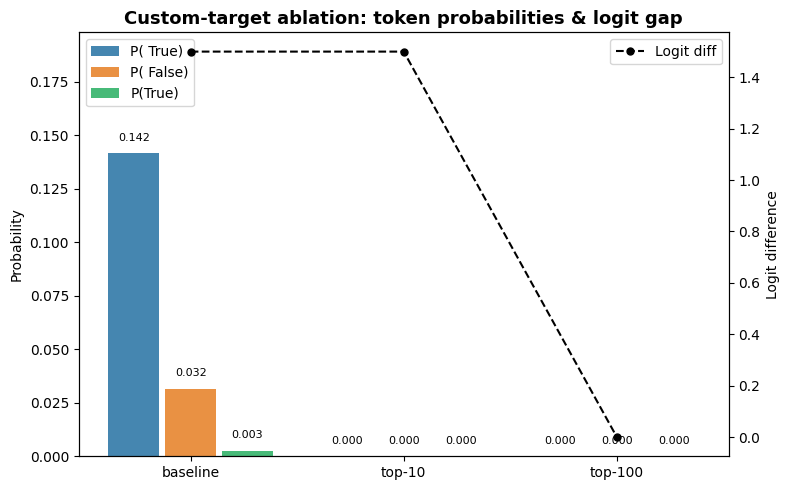

#### Top-100 ablation — full prediction shift

Token,Probability,Distribution
True,0.142,14.2%
,0.086,8.6%
A,0.059,5.9%
(,0.052,5.2%
,0.046,4.6%
Token,Probability,Distribution
,0.079,7.9%
,0.062,6.2%
The,0.054,5.4%
,0.048,4.8%


In [87]:
from IPython.display import display, Markdown

# Progressive ablation: zero out increasing numbers of custom-target features
probs_base = torch.softmax(original_logits.squeeze(0)[-1].float(), dim=-1)
groups = {"baseline": {
    "P( True)": probs_base[idx_x].item(),
    "P( False)": probs_base[idx_y].item(),
    "P(True)":  probs_base[idx_true].item(),
}}
logit_diffs = {"baseline": orig_gap}

ablation_results = {}
for n in [10, 100]:
    top_n, _ = get_top_features(graph_custom, n=n)
    abl_tuples = [
        (layer, pos, feat_idx, 0.0 * activations[layer, pos, feat_idx])
        for (layer, pos, feat_idx) in top_n
    ]
    abl_logits, _ = model.feature_intervention(input_ids, abl_tuples)
    probs_abl = torch.softmax(abl_logits.squeeze(0)[-1].float(), dim=-1)
    gap = (abl_logits.squeeze(0)[-1, idx_x] - abl_logits.squeeze(0)[-1, idx_y]).item()
    label = f"top-{n}"
    groups[label] = {
        "P(Austin)": probs_abl[idx_x].item(),
        "P(Dallas)": probs_abl[idx_y].item(),
        "P(Texas)":  probs_abl[idx_true].item(),
    }
    logit_diffs[label] = gap
    ablation_results[n] = abl_logits

display_ablation_chart(groups, logit_diffs=logit_diffs,
                       title="Custom-target ablation: token probabilities & logit gap")

# Show the full top-k comparison for the strongest ablation
strongest_n = max(ablation_results.keys())
display(Markdown(f"#### Top-{strongest_n} ablation — full prediction shift"))
display_topk(prompt, original_logits, ablation_results[strongest_n])

In [ ]:
# server.stop()